## Data Source & License

The dataset used in this analysis consists of historical trip records made available by **Motivate International Inc.**, the operator of Chicago's public bike-share system, under license from the **City of Chicago**.

- **License:** [Divvy Data License Agreement](https://divvybikes.com/data-license-agreement)
- **Access:** [divvy-tripdata.s3.amazonaws.com](https://divvy-tripdata.s3.amazonaws.com/index.html)
- **Note:** "Cyclistic" is a fictional company created for the Google Data Analytics Capstone. This analysis uses real-world public data for educational and portfolio purposes only. Raw data files are not included in this repository in compliance with the license terms.

# Phase: Prepare — Data Collection and Validation

---

## 1. Dataset

**Source:** Divvy Bikes trip data — Motivate International Inc. (public dataset from the real Chicago bike-share system)  
**Period:** May/2025 to May/2026 (13 months)  
**Files:** 13 monthly CSV files  
**License:** Open-source — Motivate International Inc.  
**Privacy:** No PII — analysis performed at group level (member vs. casual), not individual user

## 2. Problems Identified

- Incorrect file name: `202501` should be `202601` (January/2026) — verified manually, internal dates are correct
- Columns `started_at` and `ended_at` stored as `str` (require conversion to datetime)
- Trips with invalid duration: negative or very short (unlock errors)
- Null values in station columns for electric bikes parked outside docking stations

## 3. Actions Taken

- Organized files: `raw/` = original compressed files (immutable backup); `processed/` = extracted CSVs for analysis
- Manually verified `202601-divvy-tripdata.csv` — internal dates confirmed as January/2026
- Verified column consistency across all 13 files

## 4. Consistency Check

### 4.1 Identical Columns Across All Files

Verify that all 13 CSVs have exactly the same columns in the same order.

In [1]:
import glob
import pandas as pd

arquivos = sorted(glob.glob('../data/processed/*.csv'))
for f in arquivos:
    df = pd.read_csv(f, nrows=0)
    colunas = df.columns.tolist()
    print(f.split('/')[-1], '|', df.columns.tolist())
colunas

processed\202505-divvy-tripdata.csv | ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
processed\202506-divvy-tripdata.csv | ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
processed\202507-divvy-tripdata.csv | ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
processed\202508-divvy-tripdata.csv | ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
processed\202509-divvy-tripdata.csv | ['ride_id'

['ride_id',
 'rideable_type',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng',
 'member_casual']

### Result

All 13 files share the same **13 columns** in the same order:

| # | Column | Description |
|---|---|---|
| 1 | ride_id | Unique trip identifier |
| 2 | rideable_type | Bike type (classic / electric) |
| 3 | started_at | Trip start timestamp |
| 4 | ended_at | Trip end timestamp |
| 5 | start_station_name | Departure station name |
| 6 | start_station_id | Departure station ID |
| 7 | end_station_name | Arrival station name |
| 8 | end_station_id | Arrival station ID |
| 9 | start_lat | Departure latitude |
| 10 | start_lng | Departure longitude |
| 11 | end_lat | Arrival latitude |
| 12 | end_lng | Arrival longitude |
| 13 | member_casual | User type (member / casual) |

---

**Prepare phase complete.** Data located, organized, credibility verified (ROCCC), issues identified, and column structure confirmed consistent.

---

# Phase: Process — Data Cleaning and Transformation

---

**Tools:** Python (Pandas) — chosen for its ability to efficiently process large datasets (6.3M+ rows) and produce reproducible, documented analysis via Jupyter Notebook.

## 1. Data Loading

Load all 13 CSV files and combine into a single DataFrame.

In [2]:
import glob
import pandas as pd

arquivos = sorted(glob.glob('../data/processed/*.csv'))
df_combinado = pd.concat((pd.read_csv(arquivo) for arquivo in arquivos), ignore_index=True)


## 2. Initial Inspection

In [3]:
df_combinado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6351159 entries, 0 to 6351158
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    str    
 6   end_station_name    str    
 7   end_station_id      str    
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), str(9)
memory usage: 629.9 MB


**Observations:**
- 6.3 million entries representing one year of trips
- Columns `started_at` and `ended_at` are stored as `str` — need to be converted to datetime
- Geographic coordinate columns will be removed (`start_lat`, `start_lng`, `end_lat`, `end_lng`) — geographic analysis will be done using station names

In [4]:
df_combinado = df_combinado.drop(columns = ['start_lat', 'start_lng', 'end_lat', 'end_lng'], errors = 'ignore')
df_combinado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6351159 entries, 0 to 6351158
Data columns (total 9 columns):
 #   Column              Dtype
---  ------              -----
 0   ride_id             str  
 1   rideable_type       str  
 2   started_at          str  
 3   ended_at            str  
 4   start_station_name  str  
 5   start_station_id    str  
 6   end_station_name    str  
 7   end_station_id      str  
 8   member_casual       str  
dtypes: str(9)
memory usage: 436.1 MB


## 3. Cleaning and Enrichment

In [98]:
#Analisar a tabela criada
print("Column names:", df_combinado.columns)
print("Number of rows:", len(df_combinado))
print("Dimensions:", df_combinado.shape)
print("\nStatistical summary:\n", df_combinado.describe())

Column names: Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'member_casual', 'date', 'month', 'day', 'year',
       'day_of_week', 'travel_time'],
      dtype='str')
Number of rows: 6351159
Dimensions: (6351159, 15)

Statistical summary:
                        started_at                    ended_at         month  \
count                     6351159                     6351159  6.351159e+06   
mean   2025-10-20 12:07:37.500195  2025-10-20 12:23:38.551438  6.818633e+00   
min    2025-04-30 02:18:21.921000  2025-05-01 00:01:01.084000  1.000000e+00   
25%    2025-07-17 15:59:08.955500  2025-07-17 16:14:27.218000  5.000000e+00   
50%    2025-09-19 19:45:40.139000  2025-09-19 20:01:08.218000  7.000000e+00   
75%    2026-02-07 17:38:50.475500  2026-02-07 17:47:46.793000  9.000000e+00   
max    2026-05-31 23:57:08.778000  2026-05-31 23:59:46.419000  1.200000e+01   
std                 

### 3.1 Categorical Values Validation

Check for unexpected values in categorical columns.

In [100]:
colunas = ['member_casual', 'rideable_type']
for col in colunas:
    print(f'--- Unique values for: {col} ---')
    print(df_combinado[col].value_counts())

--- Unique values for: member_casual ---
member_casual
member    4068257
casual    2282902
Name: count, dtype: int64
--- Unique values for: rideable_type ---
rideable_type
electric_bike    4218872
classic_bike     2132287
Name: count, dtype: int64


Consistent values: `member_casual` contains only `member` and `casual`; `rideable_type` contains only `electric_bike` and `classic_bike`.

### 3.2 Data Type Conversion — Datetime

In [7]:
# Convert trip start and end timestamps to datetime:
df_combinado['started_at' ] = pd.to_datetime(df_combinado['started_at'])
df_combinado['ended_at' ] = pd.to_datetime(df_combinado['ended_at'])

### 3.3 Temporal Column Derivation

Extract date information to enable time-based analysis.

In [8]:
df_combinado['date'] = df_combinado['started_at'].dt.date
df_combinado['month'] = df_combinado['started_at'].dt.month
df_combinado['day'] = df_combinado['started_at'].dt.day
df_combinado['year'] = df_combinado['started_at'].dt.year
df_combinado['day_of_week'] = df_combinado['started_at'].dt.day_name()

### 3.4 Travel Time Calculation

Calculated in seconds to facilitate filtering and numeric comparisons.

In [9]:
df_combinado['travel_time'] = (df_combinado['ended_at'] - df_combinado['started_at']).dt.total_seconds()

## 4. Transformation Verification

In [10]:
df_combinado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6351159 entries, 0 to 6351158
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      str           
 8   member_casual       str           
 9   date                object        
 10  month               int32         
 11  day                 int32         
 12  year                int32         
 13  day_of_week         str           
 14  travel_time         float64       
dtypes: datetime64[us](2), float64(1), int32(3), object(1), str(8)
memory usage: 654.1+ MB


### 4.1 Invalid Trip Filter

Trips with duration <= 90 seconds (1.5 min) are considered invalid: unlock errors or immediate returns.  
Chosen threshold: **90 seconds**.

In [11]:
travel_neg = df_combinado[df_combinado['travel_time']<=90]
print(f'Found {len(travel_neg)} invalid trips (duration <= 90s)')
travel_neg

Possui 228003 viagens irrelevantes


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,date,month,day,year,day_of_week,travel_time
38,CF643B269E49B905,electric_bike,2025-05-30 09:39:56.330,2025-05-30 09:39:57.668,DuSable Lake Shore Dr & North Blvd,LF-005,DuSable Lake Shore Dr & North Blvd,LF-005,member,2025-05-30,5,30,2025,Friday,1.338
125,AACB22C635F134EE,electric_bike,2025-05-24 09:53:55.905,2025-05-24 09:54:13.409,LaSalle St & Illinois St,13430,NaN,NaN,casual,2025-05-24,5,24,2025,Saturday,17.504
180,51828189E5C89500,electric_bike,2025-05-18 18:23:01.216,2025-05-18 18:24:06.022,Wilton Ave & Diversey Pkwy*,chargingstx2,Wilton Ave & Diversey Pkwy*,chargingstx2,member,2025-05-18,5,18,2025,Sunday,64.806
442,E9807ACC86061410,electric_bike,2025-05-13 07:37:51.755,2025-05-13 07:39:21.734,Ravenswood Ave & Berteau Ave,TA1309000018,Ravenswood Ave & Irving Park Rd,TA1307000149,member,2025-05-13,5,13,2025,Tuesday,89.979
463,F2C1253C7A6D5551,electric_bike,2025-05-31 13:31:17.070,2025-05-31 13:32:40.670,Ravenswood Ave & Berteau Ave,TA1309000018,Ravenswood Ave & Irving Park Rd,TA1307000149,member,2025-05-31,5,31,2025,Saturday,83.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6351147,C26FA5766825521D,electric_bike,2026-05-24 21:53:09.627,2026-05-24 21:53:28.932,Homan Ave & Arthington Ave,CHI01835,Homan Ave & Arthington Ave,CHI01835,casual,2026-05-24,5,24,2026,Sunday,19.305
6351151,6F6E82922C78321E,electric_bike,2026-05-19 21:34:58.682,2026-05-19 21:36:03.528,Damen Ave & Thomas St (Augusta Blvd),CHI00296,Damen Ave & Thomas St (Augusta Blvd),CHI00296,casual,2026-05-19,5,19,2026,Tuesday,64.846
6351152,58C0A6E1181CED9F,electric_bike,2026-05-16 17:04:19.804,2026-05-16 17:04:38.251,Sheffield Ave & Waveland Ave,CHI00310,Sheffield Ave & Waveland Ave,CHI00310,casual,2026-05-16,5,16,2026,Saturday,18.447
6351154,F319CE4AE531709B,electric_bike,2026-05-02 15:34:11.090,2026-05-02 15:34:54.792,Sheffield Ave & Waveland Ave,CHI00310,Sheffield Ave & Waveland Ave,CHI00310,casual,2026-05-02,5,2,2026,Saturday,43.702


### 4.2 Null Values — Stations

Electric bikes can be parked outside docking stations — nulls in `start_station_name` and `end_station_name` are expected and **will not be removed**, to avoid under-representing this bike type.

In [12]:
travel_null = df_combinado.columns[df_combinado.isna().any()].tolist()
travel_null

['start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id']

Nulls identified in station columns.

**Decision:** retain these records to preserve electric bike trips without a docking station.

Create `df_clean` applying only the duration filter.

In [13]:
df_clean = df_combinado[df_combinado['travel_time']>=90 ].copy()
df_clean.info()

<class 'pandas.DataFrame'>
Index: 6123157 entries, 0 to 6351158
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             str           
 1   rideable_type       str           
 2   started_at          datetime64[us]
 3   ended_at            datetime64[us]
 4   start_station_name  str           
 5   start_station_id    str           
 6   end_station_name    str           
 7   end_station_id      str           
 8   member_casual       str           
 9   date                object        
 10  month               int32         
 11  day                 int32         
 12  year                int32         
 13  day_of_week         str           
 14  travel_time         float64       
dtypes: datetime64[us](2), float64(1), int32(3), object(1), str(8)
memory usage: 677.4+ MB


---

**df_clean ready:** 6,123,157 valid trips — cleaned data ready for analysis.

> **Note:** station nulls preserved intentionally. For station-based geographic analysis, apply `dropna` as needed in the Analyze phase.

---

# Phase: Analyze — Analysis and Insight Discovery

---

## 1. Descriptive Analysis — Trip Duration

### 1.1 Overall Distribution (`travel_time` in seconds)

In [94]:
print("Descriptive statistics for travel time:")
df_clean['travel_time'].describe()

Descriptive statistics for travel time:


count    6.123157e+06
mean     9.955370e+02
std      3.371127e+03
min      9.000000e+01
25%      3.455410e+02
50%      5.859510e+02
75%      1.019008e+03
max      9.449401e+04
Name: travel_time, dtype: float64

### 1.2 Duration by User Type

Calculate median and mean per group to identify behavioral differences.

In [95]:
print("Descriptive statistics for travel time by user type:")
df_clean.groupby('member_casual')['travel_time'].agg(['mean','median','max','min'])

Descriptive statistics for travel time by user type:


,mean,median,max,min
member_casual,,,,
casual,1406.815973,714.731,94494.011,90.001
member,768.587240,530.666,93594.221,90.000


**Observations:**
- Mean is much higher than median in both groups — indicative of a **right-skewed distribution** (long trip outliers pull the mean upward)
- Decision: use the **median** as the central comparison metric — more robust to outliers
- Casuals: median ~12 min · Members: median ~9 min

In [93]:
mediana = df_clean.groupby('member_casual')['travel_time'].median().tolist()
mediana_perc = ((mediana[0]- mediana[1])/mediana[1])*100
print(f'Difference: {mediana_perc:.2f}%')

Difference: 34.69%


> **Insight 1 — Duration:** Casuals spend 34.7% more time on bikes than members on average. Short, consistent trips for members; longer, more variable rides for casuals.

## 2. Analysis by Day of Week

### 2.1 Median Duration by Day

In [96]:
print("Median duration by day of week and user type:")
df_clean.groupby(['member_casual', 'day_of_week'])['travel_time'].median()

Median duration by day of week and user type:


member_casual  day_of_week
casual         Monday         702.2300
               Tuesday        628.7335
               Wednesday      611.3610
               Thursday       632.7295
               Friday         698.5930
               Saturday       829.1110
               Sunday         835.1085
member         Monday         514.3610
               Tuesday        520.0050
               Wednesday      519.6655
               Thursday       521.7070
               Friday         522.0635
               Saturday       576.0820
               Sunday         564.5790
Name: travel_time, dtype: float64

In [18]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday","Sunday"]
df_clean['day_of_week'] = pd.Categorical(df_clean['day_of_week'],categories=days_order, ordered=True )
df_clean.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,date,month,day,year,day_of_week,travel_time
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,LF-005,Winthrop Ave & Lawrence Ave,TA1308000021,member,2025-05-11,5,11,2025,Sunday,2919.778
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,TA1308000006,Desplaines St & Jackson Blvd,15539,member,2025-05-05,5,5,2025,Monday,598.298
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,13430,Clark St & Elm St,TA1307000039,member,2025-05-02,5,2,2025,Friday,394.200
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,13242,Damen Ave & Cortland St,13133,member,2025-05-12,5,12,2025,Monday,308.547
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,TA1305000017,Clinton St & Roosevelt Rd,WL-008,member,2025-05-01,5,1,2025,Thursday,243.727


In [97]:
print("Median duration by day of week (ordered):")
df_clean.groupby(['member_casual', 'day_of_week'])['travel_time'].median()

Median duration by day of week (ordered):


member_casual  day_of_week
casual         Monday         702.2300
               Tuesday        628.7335
               Wednesday      611.3610
               Thursday       632.7295
               Friday         698.5930
               Saturday       829.1110
               Sunday         835.1085
member         Monday         514.3610
               Tuesday        520.0050
               Wednesday      519.6655
               Thursday       521.7070
               Friday         522.0635
               Saturday       576.0820
               Sunday         564.5790
Name: travel_time, dtype: float64

> **Insight 2 — Duration by day:** Casual ride duration jumps 36% on weekends (611s to 835s). Members barely change across the week (~1 min difference) — they're on the bike regardless of the day.

In [20]:
status_resumido = df_clean.groupby(['member_casual', 'day_of_week']).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('travel_time', lambda x: x.median() / 60)
).reset_index()

print(status_resumido)

   member_casual day_of_week  number_of_rides  average_duration
0         casual      Monday           253517         11.703833
1         casual     Tuesday           242146         10.478892
2         casual   Wednesday           242819         10.189350
3         casual    Thursday           280104         10.545492
4         casual      Friday           340546         11.643217
5         casual    Saturday           451367         13.818517
6         casual      Sunday           366854         13.918475
7         member      Monday           548975          8.572683
8         member     Tuesday           619553          8.666750
9         member   Wednesday           620840          8.661092
10        member    Thursday           640490          8.695117
11        member      Friday           586444          8.701058
12        member    Saturday           499447          9.601367
13        member      Sunday           430055          9.409650


In [21]:
status_resumido.to_csv('status_resumido.csv',index = False)

> **Insight 3 — Volume by day:** Members peak mid-week (Tue–Thu). Casuals peak on Saturday and Sunday. Opposite patterns — different purposes.

### 2.2 Visualization — Volume and Duration by Day of Week

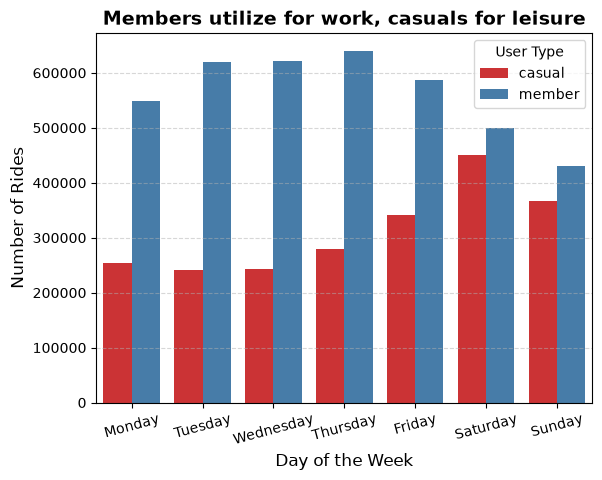

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data = status_resumido,x = 'day_of_week', y = 'number_of_rides',hue='member_casual',palette='Set1' )
plt.title('Members utilize for work, casuals for leisure', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Type')
plt.xticks(rotation=15) # Inclina o texto do eixo X se os nomes forem longos
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

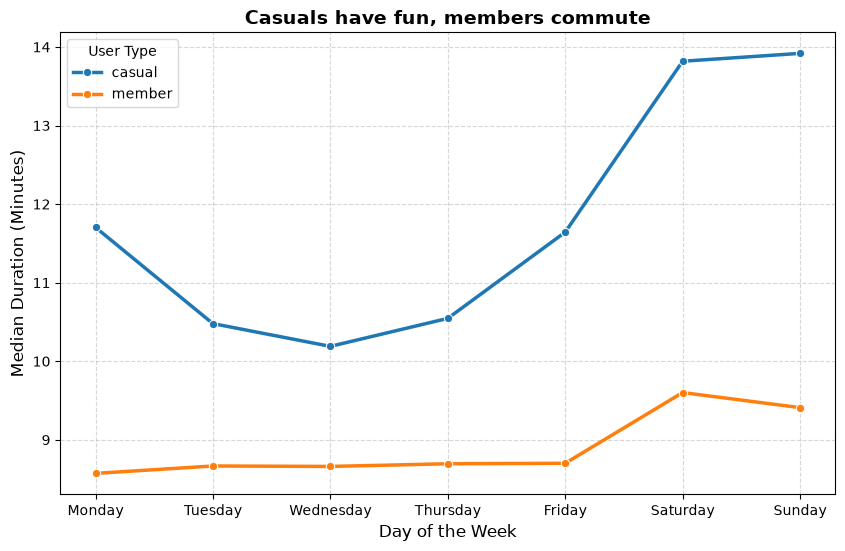

In [90]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=status_resumido, x='day_of_week', y='average_duration', hue='member_casual', marker='o', linewidth=2.5)
plt.title('Casuals have fun, members commute', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Median Duration (Minutes)', fontsize=12)
plt.legend(title='User Type')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 3. Analysis by Bike Type

Compare bike type preference (classic vs. electric) and associated duration for each user group.

In [24]:
resumo_bike = df_clean.groupby(['member_casual', 'rideable_type']).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('travel_time', lambda x: x.median() / 60)
).reset_index()

print(resumo_bike)

  member_casual  rideable_type  number_of_rides  average_duration
0        casual   classic_bike           724912         16.589375
1        casual  electric_bike          1452441         10.299167
2        member   classic_bike          1388568          9.388692
3        member  electric_bike          2557236          8.590892


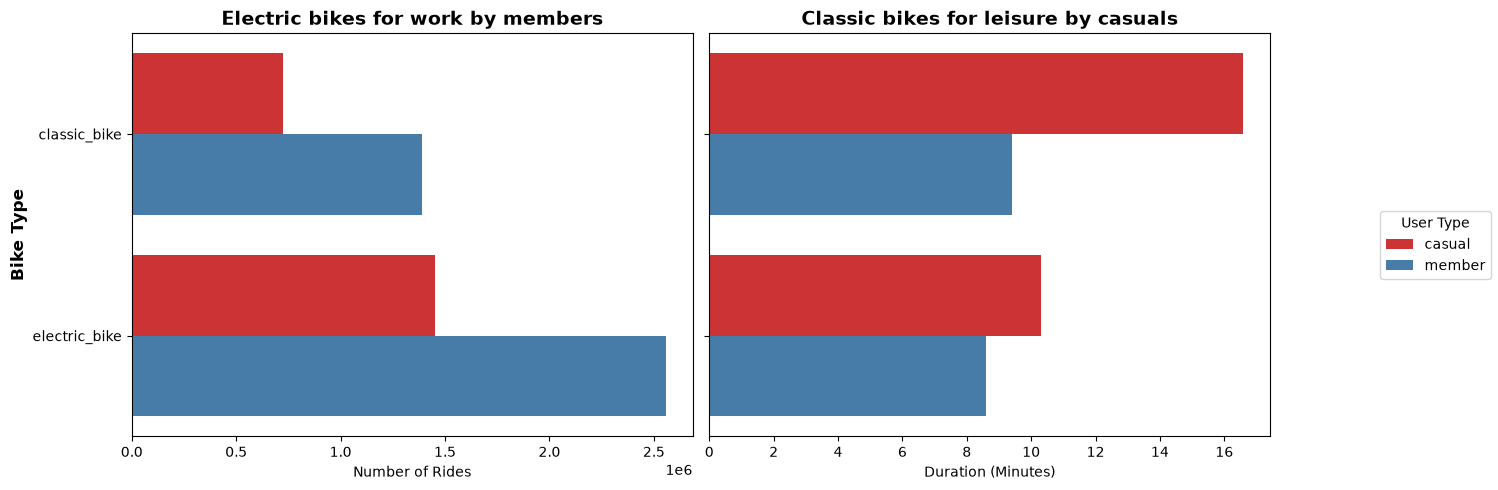

In [86]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.barplot(data = resumo_bike,x =  'number_of_rides', y = 'rideable_type',hue='member_casual',ax=axes[0],palette='Set1' )
sns.barplot(data = resumo_bike,x =  'average_duration', y = 'rideable_type',hue='member_casual',ax=axes[1],palette='Set1' )

axes[0].set_title('Electric bikes for work by members', fontsize=14, fontweight='bold')
axes[1].set_title('Classic bikes for leisure by casuals', fontsize=14, fontweight='bold')
axes[0].set_ylabel("Bike Type", fontsize=12, fontweight='bold')
axes[1].set_ylabel(" ")
#axes[1].set_yticklabels([])
axes[0].set_xlabel("Number of Rides")
axes[1].set_xlabel("Duration (Minutes)")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].get_legend().remove()
fig.legend(handles, labels, loc='center right', title='User Type')
plt.tight_layout()
fig.subplots_adjust(right=0.85) 
plt.show()

## 4. Seasonal Analysis

Filter starting from June 2025 to obtain 12 unique months without overlap — the original dataset has May in both 2025 and 2026, which would double-count when grouping by month number.

In [87]:
df_filtrado = df_clean[df_clean['started_at'] > '2025-06-01']
resumo_mes = df_filtrado.groupby(['member_casual', 'month']).agg(
number_of_rides=('ride_id', 'count'),
average_duration=('travel_time', lambda x: x.median() / 60)
).reset_index()
resumo_mes

,member_casual,month,number_of_rides,average_duration
0,casual,1,23724,7.190325
1,casual,2,39860,8.260417
2,casual,3,84258,9.992000
3,casual,4,126289,10.128800
4,casual,5,234371,11.946483
5,casual,6,277518,13.527625
6,casual,7,306879,13.131283
7,casual,8,321714,13.585717
8,casual,9,253465,12.069050
9,casual,10,213194,10.826592


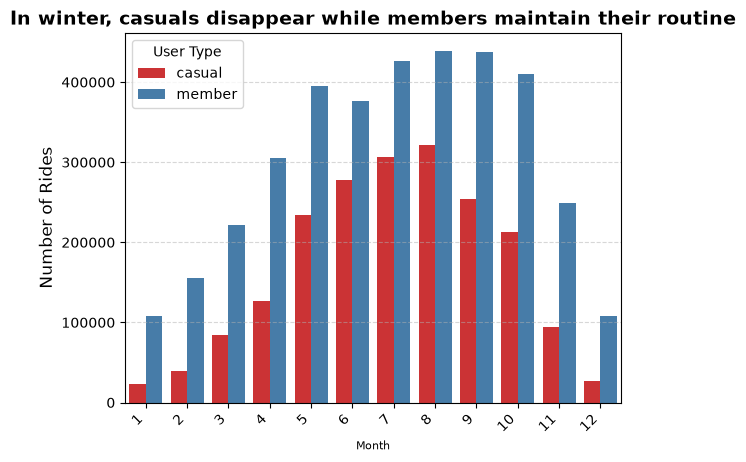

In [88]:
sns.barplot(data = resumo_mes,x = 'month', y = 'number_of_rides',hue='member_casual',palette='Set1' )
plt.title('In winter, casuals disappear while members maintain their routine', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=8)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Type')
plt.xticks(rotation=45, ha='right') # Inclina o texto do eixo X se os nomes forem longos
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [92]:
valores_maximos = resumo_mes.groupby('member_casual')['average_duration'].max().tolist()
valores_maximos
diferenca = ((valores_maximos[0] - valores_maximos[1])/valores_maximos[1])*100
print(f'Summer usage difference: { diferenca:.2f}%')

Summer usage difference: 39.56%


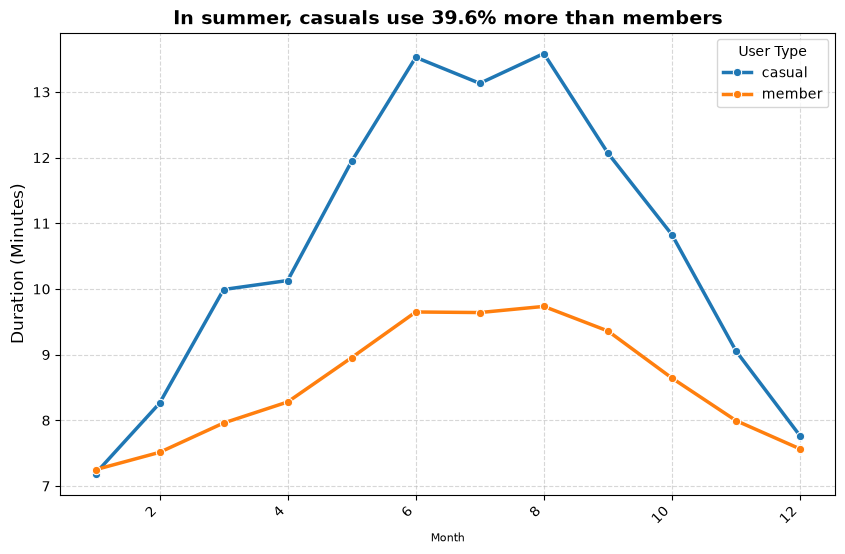

In [89]:

plt.figure(figsize=(10, 6))
sns.lineplot(data = resumo_mes,x = 'month', y='average_duration', hue='member_casual', marker='o', linewidth=2.5)
plt.title(f'In summer, casuals use {diferenca:.1f}% more than members', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=8)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='User Type')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

> **Insight 4 — Seasonality:** Both groups drop in winter, but casuals fall off a cliff: ~92% reduction from summer peak to January. Members drop ~75% but keep going — biking is already part of their routine.

> **Insight 5 — Bike type:** Both groups lean toward electric bikes by volume (65–67%). But casual riders on classic bikes log the longest trips (~16 min) — slow, recreational, no rush.

In [28]:
resumo_mes.to_csv('resumo_mes.csv',index = False)
resumo_bike.to_csv('resumo_bike.csv',index = False)

---

# Phase: Act — Conclusions and Recommendations

---

## Summary

Analysis of **6,123,157 Cyclistic trips** (Jun/2025–May/2026):

| Dimension | Members | Casuals |
|---|---|---|
| **Primary use** | Daily commute | Leisure |
| **Median duration** | ~9 min | ~12 min (+34.7%) |
| **Weekly peak (volume)** | Tue–Thu | Sat–Sun |
| **Duration change on weekends** | ~1 min | +36% |
| **Winter volume drop** | -75% | -92% |
| **Classic bike duration** | 9.4 min | 16.6 min (+77%) |

Members and casuals are on opposite ends of the same product. Converting casuals means showing up where they already are — summer, weekends, leisure spots — and making the membership feel worth it.

## Recommendation 1 — Summer Campaign at Leisure Spots

Casual riders are already out biking on weekends and in summer. The idea is to catch them at parks and tourist spots and make the case for turning it into a daily habit.

> *"You already love cycling. Make it your everyday routine."*

**Data behind this:**
- Casual volume on Saturday is 78% higher than on Tuesday
- Weekend ride duration is 36% longer than weekdays

**Owner:** Marketing team &nbsp; **When:** Before summer (May/Jun)

## Recommendation 2 — Discounted Summer Membership

Casuals drop 92% in volume from summer to January — the window to convert them is summer. A discounted membership plan during Jun–Aug gives active casuals a low-friction reason to commit. Someone who bikes through summer has already built the habit; they're more likely to keep the subscription when it gets cold.

**Data behind this:**
- Casual volume: ~322K rides in Aug → ~24K in Jan (-92.5%)
- Members maintain consistent usage year-round once subscribed

**Owner:** Product + Marketing &nbsp; **When:** June

## Recommendation 3 — Target Classic Bike Casual Riders

Casual riders on classic bikes log 77% more ride time than members on the same bike (16.6 min vs. 9.4 min). They're heavy users who just haven't subscribed. That makes them the easiest group to convert — they already have the habit, they just need the offer.

**Data behind this:**
- Casuals on classic bikes: median 16.6 min
- Members on classic bikes: median 9.4 min
- Difference: +77%

**Owner:** Marketing / CRM &nbsp; **When:** Jun–Aug

## Additional Data That Would Help

- **Demographics** — age, home-to-work distance; spot casuals with commute potential
- **Pricing data** — how many rides/month does it take for a membership to pay off?
- **Qualitative research** — why don't frequent casuals subscribe? What's the actual barrier?
- **Location detail** — which routes do recurring casuals take? Are they commute-adjacent?
- **Retention data** — how long do converted casuals stay as members?

---

**Analysis complete:** Ask ✅ &nbsp; Prepare ✅ &nbsp; Process ✅ &nbsp; Analyze ✅ &nbsp; Share ✅ &nbsp; Act ✅

> Data: Divvy Bikes trip records &nbsp;·&nbsp; Source: Motivate International Inc. &nbsp;·&nbsp; Period: Jun/2025–May/2026 &nbsp;·&nbsp; 6,123,157 trips